## **Imports**

In [74]:
import os, glob, math, random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

## **File Paths**

In [75]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
DRIVE_BASE = "/content/drive/MyDrive"
SEG_BASE   = os.path.join(DRIVE_BASE, "seg")

IMG_DIR_TRAIN = os.path.join(SEG_BASE, "images", "train")
IMG_DIR_VAL   = os.path.join(SEG_BASE, "images", "val")

LBL_DIR_TRAIN = os.path.join(SEG_BASE, "labels", "train")
LBL_DIR_VAL   = os.path.join(SEG_BASE, "labels", "val")

## **Hyperparameters**

In [77]:
IMG_H, IMG_W = 256, 256
IMG_SIZE = (IMG_H, IMG_W)
BATCH_SIZE = 19
EPOCHS = 15

In [78]:
CLASS_NAMES = ["background", "person", "car", "bus", "truck","traffic_sign"]
OBJ_CLASSES = len(CLASS_NAMES)
LANE_CLASSES = 2                 # binary: 0 background, 1 lane

In [79]:
CLASS_MAPPING_BDD_TO_OBJ = {
    11: 1,   # person -> 1
    13: 2,   # car -> 2
    15: 3,   # bus -> 3
    14: 4,   # truck -> 4
    7:5
    # 0 (road) will be used for lane head (not object)
}
# which train_id counts as lane? BDD uses 0 for road/drivable
LANE_TRAIN_ID = 0

## **Images and Labels**

In [80]:
import os, glob

print("Train label samples:")
print(glob.glob(os.path.join(LBL_DIR_TRAIN, "*"))[:20])


Train label samples:
['/content/drive/MyDrive/seg/labels/train/5dc8f40e-4300ba8f_train_id.png', '/content/drive/MyDrive/seg/labels/train/1798f471-f9facd88_train_id.png', '/content/drive/MyDrive/seg/labels/train/7fc69e06-c26e122e_train_id.png', '/content/drive/MyDrive/seg/labels/train/072f9d2d-5534d167_train_id.png', '/content/drive/MyDrive/seg/labels/train/3e3414ed-dbb81fff_train_id.png', '/content/drive/MyDrive/seg/labels/train/137a0efc-67956117_train_id.png', '/content/drive/MyDrive/seg/labels/train/2c0d8b80-00000000_train_id.png', '/content/drive/MyDrive/seg/labels/train/4adb062d-bbc20000_train_id.png', '/content/drive/MyDrive/seg/labels/train/7baad8d8-00000000_train_id.png', '/content/drive/MyDrive/seg/labels/train/c2e294a9-cd5c3b02_train_id.png', '/content/drive/MyDrive/seg/labels/train/3dab4537-763cdd5e_train_id.png', '/content/drive/MyDrive/seg/labels/train/44d5e383-c58840d5_train_id.png', '/content/drive/MyDrive/seg/labels/train/78f5ea10-3b438287_train_id.png', '/content/drive/

In [81]:
train_images = sorted(glob.glob(os.path.join(IMG_DIR_TRAIN, "*.jpg")))
train_labels = sorted(glob.glob(os.path.join(LBL_DIR_TRAIN, "*_train_id.png")))  # use train_id masks
val_images = sorted(glob.glob(os.path.join(IMG_DIR_VAL, "*.jpg")))
val_labels = sorted(glob.glob(os.path.join(LBL_DIR_VAL, "*_train_id.png")))

print("Train images:", len(train_images), "Train labels:", len(train_labels))
print("Val   images:", len(val_images),   "Val   labels:", len(val_labels))


Train images: 7000 Train labels: 7000
Val   images: 1000 Val   labels: 1000


In [82]:
def pair_images_labels(img_list, lbl_list):
    lbl_map = { os.path.basename(f).replace("_train_id.png",".jpg"): f for f in lbl_list }
    imgs = []
    lbls = []
    for img in img_list:
        name = os.path.basename(img)
        if name in lbl_map:
            imgs.append(img)
            lbls.append(lbl_map[name])
    return imgs, lbls

train_images, train_labels = pair_images_labels(train_images, train_labels)
val_images, val_labels     = pair_images_labels(val_images, val_labels)

print("Paired - Train:", len(train_images), "Val:", len(val_images))

Paired - Train: 7000 Val: 1000


## **Data Loaders**

In [83]:
def remap_mask_array(arr):
    """
    arr: 2D numpy array of train_id values from BDD *_train_id.png
    returns:
      obj_map: int array with values in [0..OBJ_CLASSES-1] (0=background)
      lane_map: int array 0/1 where 1 if arr == LANE_TRAIN_ID
    """
    obj_map = np.zeros_like(arr, dtype=np.uint8)
    for orig, new in CLASS_MAPPING_BDD_TO_OBJ.items():
        obj_map[arr == orig] = new
    # everything else stays 0 (background)
    lane_map = (arr == LANE_TRAIN_ID).astype(np.uint8)
    return obj_map, lane_map

# compute remapped pixel counts on validation masks
print("Computing validation pixel counts")
val_pixel_counts = Counter()
val_image_counts = Counter()

for p in tqdm(val_labels):
    arr = np.array(Image.open(p))
    obj_map, lane_map = remap_mask_array(arr)
    unique, counts = np.unique(obj_map, return_counts=True)
    for u,c in zip(unique, counts):
        val_pixel_counts[int(u)] += int(c)
        val_image_counts[int(u)] += 1
    # also count lane pixels under a special key (we won't use as obj class)
    lane_pixels = int(np.sum(lane_map))
    val_pixel_counts['lane'] += lane_pixels

print("Validation pixel counts (remapped object classes):")
for i,name in enumerate(CLASS_NAMES):
    print(f"{i:2d} {name:12s} pixels = {val_pixel_counts.get(i,0)} images_with = {val_image_counts.get(i,0)}")
print("lane pixels:", val_pixel_counts['lane'])

Computing validation pixel counts


100%|██████████| 1000/1000 [00:31<00:00, 31.70it/s]

Validation pixel counts (remapped object classes):
 0 background   pixels = 818195675 images_with = 1000
 1 person       pixels = 2527313 images_with = 379
 2 car          pixels = 83605858 images_with = 971
 3 bus          pixels = 5795084 images_with = 136
 4 truck        pixels = 9351817 images_with = 331
 5 traffic_sign pixels = 2124253 images_with = 776
lane pixels: 199047305


In [84]:
# build array of frequencies for object classes
total_obj_pixels = sum(val_pixel_counts[i] for i in range(OBJ_CLASSES))
# guard
if total_obj_pixels == 0:
    raise RuntimeError("No object pixels found in validation. Check label mapping and file pairing.")

freqs = np.array([ val_pixel_counts.get(i,0) / (total_obj_pixels + 1e-12) for i in range(OBJ_CLASSES)], dtype=np.float32)

# inverse sqrt freq
raw_weights = 1.0 / (np.sqrt(freqs + 1e-12))
# scale down background weight (index 0) to reduce dominance
raw_weights[0] = raw_weights[0] * 0.2

# normalize so mean weight == 1.0 (keeps learning rate behavior sane)
raw_weights = raw_weights / np.mean(raw_weights)

print("Raw inverse-sqrt weights (scaled bg):", raw_weights)
class_weights = tf.constant(raw_weights, dtype=tf.float32)   # vector length OBJ_CLASSES


Raw inverse-sqrt weights (scaled bg): [0.01929796 1.7361231  0.30185035 1.1465162  0.9025308  1.8936814 ]


In [85]:
dice_weights = tf.constant(class_weights, dtype=tf.float32)
print(dice_weights)

tf.Tensor([0.01929796 1.7361231  0.30185035 1.1465162  0.9025308  1.8936814 ], shape=(6,), dtype=float32)


In [86]:
def load_mask_np(mask_path_bytes):
    # mask_path_bytes could be bytes
    p = mask_path_bytes.decode() if isinstance(mask_path_bytes, (bytes,bytearray)) else str(mask_path_bytes)
    m = cv2.imread(p, cv2.IMREAD_UNCHANGED)
    if m is None:
        raise FileNotFoundError("Mask not found: " + p)
    if m.ndim == 3:
        m = m[...,0]
    # resize with NEAREST so labels remain integer
    m = cv2.resize(m, (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST)
    obj_map = np.zeros_like(m, dtype=np.uint8)
    for orig, new in CLASS_MAPPING_BDD_TO_OBJ.items():
        obj_map[m == orig] = new
    # lane map
    lane_map = (m == LANE_TRAIN_ID).astype(np.uint8)[..., None]
    return obj_map.astype(np.uint8), lane_map.astype(np.uint8)

In [87]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image_tf(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.image.convert_image_dtype(img, tf.float32)  # 0..1
    return img

def load_pair(img_path, mask_path):
    img = load_image_tf(img_path)
    obj_map, lane_map = tf.numpy_function(load_mask_np, [mask_path], [tf.uint8, tf.uint8])
    # set shapes
    obj_map.set_shape((IMG_H, IMG_W))
    lane_map.set_shape((IMG_H, IMG_W, 1))
    # Keras expects integer y_true for sparse losses: leave obj_map as int
    return img, {"obj_mask": tf.cast(obj_map, tf.int32), "lane_mask": tf.cast(lane_map, tf.float32)}

def make_dataset(img_list, lbl_list, batch=BATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((img_list, lbl_list))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(1000, len(img_list)))
    ds = ds.map(load_pair, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_images, train_labels, shuffle=True)
val_ds   = make_dataset(val_images, val_labels, shuffle=False)

## **Loss**

In [88]:
def weighted_focal_loss(class_weights, gamma=2.0):
    cw = tf.cast(class_weights, tf.float32)
    def loss(y_true, y_pred_logits):
        """
        y_true: (B,H,W) integer labels 0..C-1
        y_pred_logits: (B,H,W,C) logits
        """
        y_true_i = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true_i, depth=OBJ_CLASSES)   # (B,H,W,C)
        probs = tf.nn.softmax(y_pred_logits, axis=-1)
        probs = tf.clip_by_value(probs, 1e-6, 1.0)
        # per-pixel CE
        ce = -tf.reduce_sum(y_true_oh * tf.math.log(probs), axis=-1)   # (B,H,W)
        # per-pixel class weight
        weight_map = tf.reduce_sum(y_true_oh * cw, axis=-1)            # (B,H,W)
        pt = tf.reduce_sum(y_true_oh * probs, axis=-1)                # p_t
        focal_term = (1.0 - pt) ** gamma
        loss_map = weight_map * focal_term * ce
        return tf.reduce_mean(loss_map)
    return loss

def dice_loss_weighted(y_true, y_pred_logits, dice_weights):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), depth=OBJ_CLASSES)
    probs = tf.nn.softmax(y_pred_logits, axis=-1)

    axes = [1,2]
    intersection = tf.reduce_sum(probs * y_true_oh, axis=axes)
    denom = tf.reduce_sum(probs + y_true_oh, axis=axes)

    dice_per_class = (2*intersection + 1e-6) / (denom + 1e-6)
    dice_weighted = tf.reduce_sum(dice_per_class * dice_weights) / tf.reduce_sum(dice_weights)

    return 1 - dice_weighted

def total_obj_loss(class_weights, dice_weights, gamma=2.0):
    focal_fn = weighted_focal_loss(class_weights, gamma)

    def loss(y_true, y_pred):
        fl = focal_fn(y_true, y_pred)
        dl = dice_loss_weighted(y_true, y_pred, dice_weights)
        return fl + dl

    return loss

# lane loss: use binary_crossentropy from logits for stability
bce_loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def lane_loss(y_true, y_pred_logits):
    # y_true: (B,H,W,1) float32 0/1 ; y_pred_logits: (B,H,W,1)
    return tf.reduce_mean(bce_loss_fn(y_true, y_pred_logits))


## **Model**

In [89]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    return x


def build_two_head_mobilenetv2(
    input_shape=(*IMG_SIZE, 3),
    num_obj_classes=OBJ_CLASSES
):
    # --- Encoder: MobileNetV2 ---
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )

    # Skip feature layers (fixed MobileNetV2 names)
    skip1 = base.get_layer("block_1_expand_relu").output   # 256x256
    skip2 = base.get_layer("block_3_expand_relu").output   # 128x128
    skip3 = base.get_layer("block_6_expand_relu").output   # 64x64
    skip4 = base.get_layer("block_13_expand_relu").output  # 32x32

    bottleneck = base.get_layer("block_16_project").output  # 16x16

    # --- Decoder ---
    # Up 1
    d = layers.UpSampling2D()(bottleneck)
    d = layers.Concatenate()([d, skip4])
    d = conv_block(d, 256)

    # Up 2
    d = layers.UpSampling2D()(d)
    d = layers.Concatenate()([d, skip3])
    d = conv_block(d, 128)

    # Up 3
    d = layers.UpSampling2D()(d)
    d = layers.Concatenate()([d, skip2])
    d = conv_block(d, 64)

    # Up 4
    d = layers.UpSampling2D()(d)
    d = layers.Concatenate()([d, skip1])
    d = conv_block(d, 32)

    # Final up
    d = layers.UpSampling2D()(d)
    d = conv_block(d, 32)

    shared = d  # Shared decoder output

    # --- Object head (logits no activation) ---
    obj = layers.Conv2D(64, 3, padding="same", activation="relu")(shared)
    obj = layers.Conv2D(num_obj_classes, 1, padding="same", name="obj_mask")(obj)
    # no activation — softmax will be inside your loss
    # obj shape: (H, W, OBJ_CLASSES)

    # --- Lane head (logits no activation) ---
    lane = layers.Conv2D(32, 3, padding="same", activation="relu")(shared)
    lane = layers.Conv2D(1, 1, padding="same", name="lane_mask")(lane)
    # no activation — you use BCE(from_logits=True)

    model = models.Model(inputs=base.input, outputs={"obj_mask": obj, "lane_mask": lane})
    return model


# Build the model
model = build_two_head_mobilenetv2()
model.summary()


/tmp/ipython-input-1950215898.py:18: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 5,460,295 (20.83 MB)

 Trainable params: 5,427,335 (20.70 MB)

 Non-trainable params: 32,960 (128.75 KB)

In [90]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss={
        "obj_mask": total_obj_loss(class_weights, dice_weights),
        "lane_mask": lane_loss
    },
    metrics={"obj_mask": ["accuracy"]}
)


In [91]:
ckpt_path = os.path.join(DRIVE_BASE, "m1.h5")
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor='val_obj_mask_accuracy',
                                       save_best_only=True, mode='max', verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_obj_mask_accuracy', factor=0.5, patience=3, mode='max', verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_obj_mask_accuracy', patience=5, restore_best_weights=True, mode='max')
]

## **Training**

In [92]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - lane_mask_loss: 0.3510 - loss: 0.4821 - obj_mask_accuracy: 0.5917 - obj_mask_loss: 0.1312
Epoch 1: val_obj_mask_accuracy improved from -inf to 0.93047, saving model to /content/drive/MyDrive/m1.h5


369/369 ━━━━━━━━━━━━━━━━━━━━ 994s 2s/step - lane_mask_loss: 0.3506 - loss: 0.4800 - obj_mask_accuracy: 0.5923 - obj_mask_loss: 0.1294 - val_lane_mask_loss: 0.1452 - val_loss: -0.2321 - val_obj_mask_accuracy: 0.9305 - val_obj_mask_loss: -0.3665 - learning_rate: 1.0000e-04
Epoch 2/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - lane_mask_loss: 0.1370 - loss: -1.4072 - obj_mask_accuracy: 0.9244 - obj_mask_loss: -1.5442
Epoch 2: val_obj_mask_accuracy improved from 0.93047 to 0.95010, saving model to /content/drive/MyDrive/m1.h5


369/369 ━━━━━━━━━━━━━━━━━━━━ 143s 387ms/step - lane_mask_loss: 0.1370 - loss: -1.4075 - obj_mask_accuracy: 0.9245 - obj_mask_loss: -1.5445 - val_lane_mask_loss: 0.1229 - val_loss: -1.0019 - val_obj_mask_accuracy: 0.9501 - val_obj_mask_loss: -1.1108 - learning_rate: 1.0000e-04
Epoch 3/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - lane_mask_loss: 0.1286 - loss: -1.8551 - obj_mask_accuracy: 0.9416 - obj_mask_loss: -1.9837
Epoch 3: val_obj_mask_accuracy improved from 0.95010 to 0.95090, saving model to /content/drive/MyDrive/m1.h5


369/369 ━━━━━━━━━━━━━━━━━━━━ 205s 396ms/step - lane_mask_loss: 0.1286 - loss: -1.8553 - obj_mask_accuracy: 0.9416 - obj_mask_loss: -1.9838 - val_lane_mask_loss: 0.1197 - val_loss: -1.4067 - val_obj_mask_accuracy: 0.9509 - val_obj_mask_loss: -1.5101 - learning_rate: 1.0000e-04
Epoch 4/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - lane_mask_loss: 0.1260 - loss: -2.2254 - obj_mask_accuracy: 0.9491 - obj_mask_loss: -2.3514
Epoch 4: val_obj_mask_accuracy improved from 0.95090 to 0.95650, saving model to /content/drive/MyDrive/m1.h5


369/369 ━━━━━━━━━━━━━━━━━━━━ 142s 385ms/step - lane_mask_loss: 0.1260 - loss: -2.2254 - obj_mask_accuracy: 0.9491 - obj_mask_loss: -2.3515 - val_lane_mask_loss: 0.1144 - val_loss: -1.3736 - val_obj_mask_accuracy: 0.9565 - val_obj_mask_loss: -1.4726 - learning_rate: 1.0000e-04
Epoch 5/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - lane_mask_loss: 0.1228 - loss: -2.4850 - obj_mask_accuracy: 0.9543 - obj_mask_loss: -2.6077
Epoch 5: val_obj_mask_accuracy improved from 0.95650 to 0.95662, saving model to /content/drive/MyDrive/m1.h5


...

369/369 ━━━━━━━━━━━━━━━━━━━━ 143s 385ms/step - lane_mask_loss: 0.1224 - loss: -2.7514 - obj_mask_accuracy: 0.9581 - obj_mask_loss: -2.8738 - val_lane_mask_loss: 0.1168 - val_loss: -1.6803 - val_obj_mask_accuracy: 0.9574 - val_obj_mask_loss: -1.7820 - learning_rate: 1.0000e-04
Epoch 7/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - lane_mask_loss: 0.1186 - loss: -3.0080 - obj_mask_accuracy: 0.9614 - obj_mask_loss: -3.1267
Epoch 7: val_obj_mask_accuracy improved from 0.95741 to 0.96198, saving model to /content/drive/MyDrive/m1.h5


369/369 ━━━━━━━━━━━━━━━━━━━━ 142s 384ms/step - lane_mask_loss: 0.1187 - loss: -3.0079 - obj_mask_accuracy: 0.9614 - obj_mask_loss: -3.1266 - val_lane_mask_loss: 0.1160 - val_loss: -1.4267 - val_obj_mask_accuracy: 0.9620 - val_obj_mask_loss: -1.5247 - learning_rate: 1.0000e-04
Epoch 8/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - lane_mask_loss: 0.1172 - loss: -3.1562 - obj_mask_accuracy: 0.9640 - obj_mask_loss: -3.2734
Epoch 8: val_obj_mask_accuracy improved from 0.96198 to 0.96382, saving model to /content/drive/MyDrive/m1.h5


369/369 ━━━━━━━━━━━━━━━━━━━━ 148s 399ms/step - lane_mask_loss: 0.1172 - loss: -3.1562 - obj_mask_accuracy: 0.9640 - obj_mask_loss: -3.2734 - val_lane_mask_loss: 0.1095 - val_loss: -1.4782 - val_obj_mask_accuracy: 0.9638 - val_obj_mask_loss: -1.5728 - learning_rate: 1.0000e-04
Epoch 9/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - lane_mask_loss: 0.1175 - loss: -3.2897 - obj_mask_accuracy: 0.9657 - obj_mask_loss: -3.4073
Epoch 9: val_obj_mask_accuracy did not improve from 0.96382
369/369 ━━━━━━━━━━━━━━━━━━━━ 139s 377ms/step - lane_mask_loss: 0.1175 - loss: -3.2898 - obj_mask_accuracy: 0.9657 - obj_mask_loss: -3.4073 - val_lane_mask_loss: 0.1198 - val_loss: -1.7995 - val_obj_mask_accuracy: 0.9619 - val_obj_mask_loss: -1.9029 - learning_rate: 1.0000e-04
Epoch 10/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - lane_mask_loss: 0.1146 - loss: -3.5012 - obj_mask_accuracy: 0.9670 - obj_mask_loss: -3.6158
Epoch 10: val_obj_mask_accuracy did not improve from 0.96382
369/369 ━━━━━━━━━━━━━━━━━━━━

369/369 ━━━━━━━━━━━━━━━━━━━━ 145s 391ms/step - lane_mask_loss: 0.1084 - loss: -4.0308 - obj_mask_accuracy: 0.9733 - obj_mask_loss: -4.1392 - val_lane_mask_loss: 0.1073 - val_loss: -1.7418 - val_obj_mask_accuracy: 0.9648 - val_obj_mask_loss: -1.8339 - learning_rate: 5.0000e-05
Epoch 14/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - lane_mask_loss: 0.1067 - loss: -4.1218 - obj_mask_accuracy: 0.9731 - obj_mask_loss: -4.2284
Epoch 14: val_obj_mask_accuracy improved from 0.96482 to 0.96645, saving model to /content/drive/MyDrive/m1.h5


369/369 ━━━━━━━━━━━━━━━━━━━━ 200s 385ms/step - lane_mask_loss: 0.1067 - loss: -4.1217 - obj_mask_accuracy: 0.9731 - obj_mask_loss: -4.2284 - val_lane_mask_loss: 0.1077 - val_loss: -1.6027 - val_obj_mask_accuracy: 0.9665 - val_obj_mask_loss: -1.6938 - learning_rate: 5.0000e-05
Epoch 15/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - lane_mask_loss: 0.1079 - loss: -4.1856 - obj_mask_accuracy: 0.9741 - obj_mask_loss: -4.2934
Epoch 15: val_obj_mask_accuracy did not improve from 0.96645
369/369 ━━━━━━━━━━━━━━━━━━━━ 140s 377ms/step - lane_mask_loss: 0.1079 - loss: -4.1855 - obj_mask_accuracy: 0.9741 - obj_mask_loss: -4.2933 - val_lane_mask_loss: 0.1036 - val_loss: -1.6589 - val_obj_mask_accuracy: 0.9660 - val_obj_mask_loss: -1.7478 - learning_rate: 5.0000e-05


In [93]:
# Save final model
save_path = os.path.join(DRIVE_BASE, "m1.h5")
model.save(save_path)
print("Saved H5 model to:", save_path)

Saved H5 model to: /content/drive/MyDrive/m1.h5


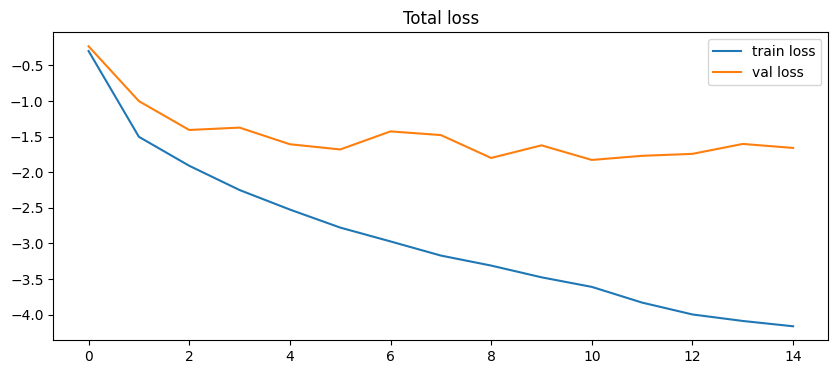

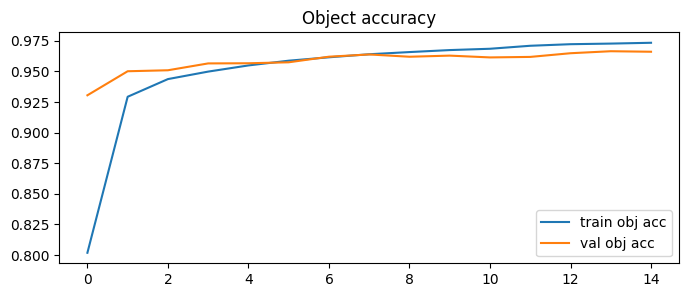

In [94]:
import seaborn as sns
def plot_history(history):
    hist = history.history
    plt.figure(figsize=(10,4))
    plt.plot(hist['loss'], label='train loss')
    plt.plot(hist['val_loss'], label='val loss')
    plt.title('Total loss')
    plt.legend(); plt.show()

    # Object accuracy
    key_obj = 'obj_mask_accuracy'
    if key_obj in hist:
        plt.figure(figsize=(8,3))
        plt.plot(hist[key_obj], label='train obj acc')
        plt.plot(hist.get('val_'+key_obj, []), label='val obj acc')
        plt.title('Object accuracy')
        plt.legend(); plt.show()

plot_history(history)

## **Metrics**

In [95]:
def compute_per_class_iou(model, dataset, num_classes):
    total_intersect = np.zeros(num_classes, dtype=np.float64)
    total_union     = np.zeros(num_classes, dtype=np.float64)

    for batch in tqdm(dataset, desc="Computing IoU"):
        imgs, masks = batch
        y_true = masks["obj_mask"].numpy()  # (B,H,W) ints
        preds = model.predict(imgs, verbose=0)
        pred_logits = preds["obj_mask"]
        y_pred = np.argmax(pred_logits, axis=-1)

        for cls in range(num_classes):
            intersect = np.logical_and(y_true == cls, y_pred == cls).sum()
            union     = np.logical_or(y_true == cls, y_pred == cls).sum()
            total_intersect[cls] += intersect
            total_union[cls] += union

    iou = total_intersect / (total_union + 1e-7)
    return iou

per_class_ious = compute_per_class_iou(model, val_ds, OBJ_CLASSES)
for idx, name in enumerate(CLASS_NAMES):
    print(f"{name:12s} IoU = {per_class_ious[idx]:.4f}")

Computing IoU: 100%|██████████| 53/53 [00:40<00:00,  1.29it/s]

background   IoU = 0.9710
person       IoU = 0.3722
car          IoU = 0.7966
bus          IoU = 0.4391
truck        IoU = 0.3079
traffic_sign IoU = 0.2179


## **Predictions**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


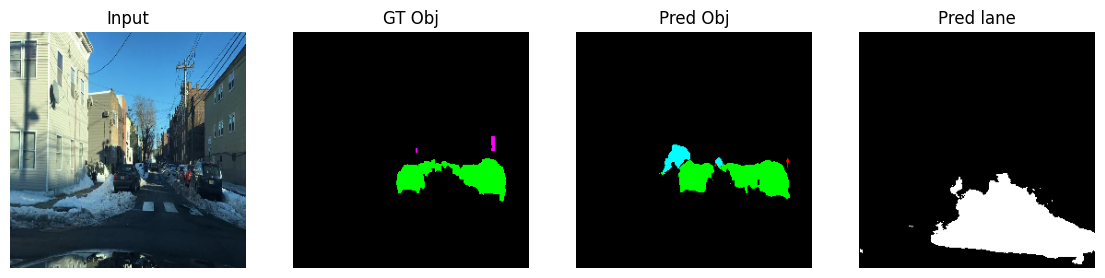

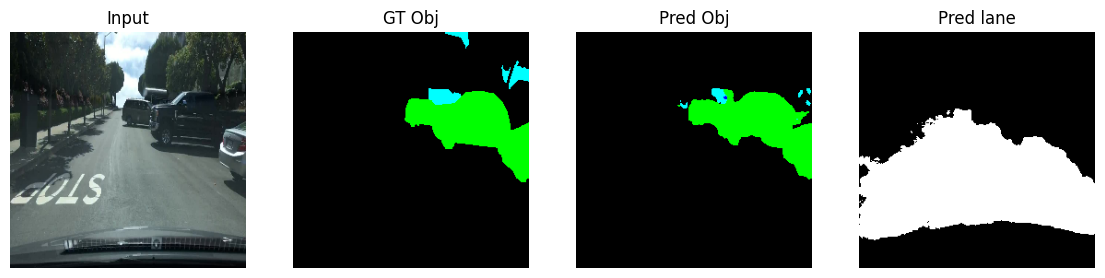

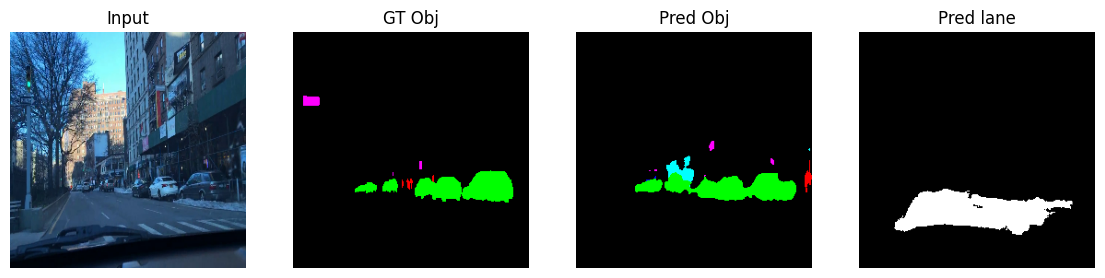

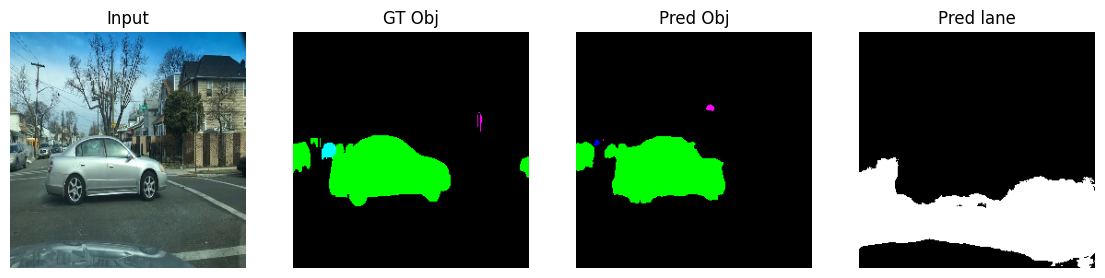

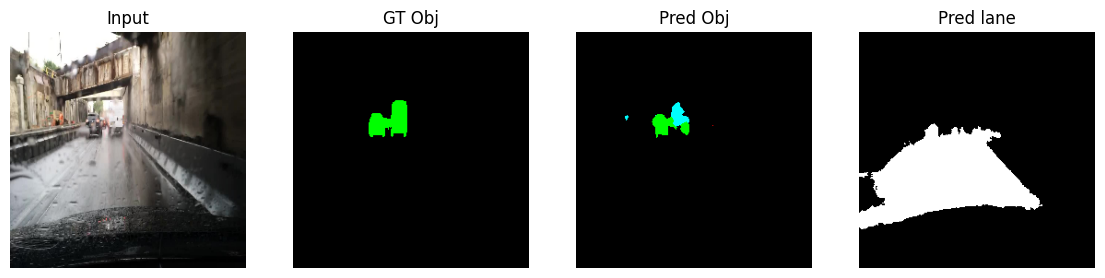

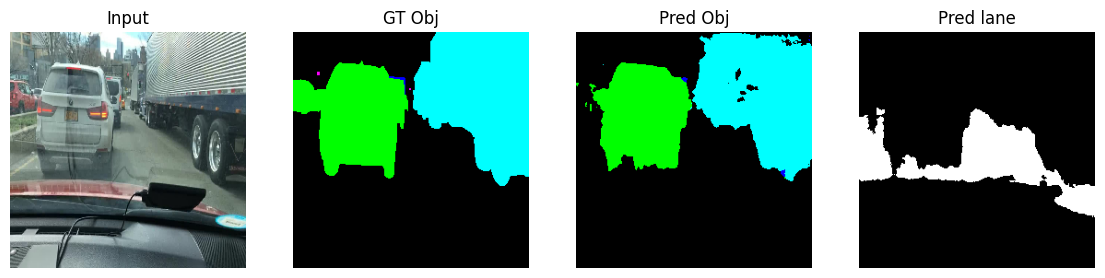

In [98]:
CLASS_COLORS = {
    0: (0,0,0),         # bg black
    1: (255,0,0),       # person red
    2: (0,255,0),       # car green
    3: (0,0,255),       # bus blue
    4: (0,255,255),
    5: (255,0,255)
}

def colorize_mask(mask2d):
    h,w = mask2d.shape
    out = np.zeros((h,w,3), dtype=np.uint8)
    for cid, col in CLASS_COLORS.items():
        out[mask2d == cid] = col
    return out

def visualize_predictions(model, dataset, n=5):
    for imgs, masks in dataset.take(1):
        preds = model.predict(imgs)
        pred_obj = np.argmax(preds["obj_mask"], axis=-1)
        pred_lane = (preds["lane_mask"][...,0] > 0.0).astype(np.uint8)  # logits -> threshold 0
        imgs_np = imgs.numpy()
        for i in range(min(n, imgs_np.shape[0])):
            inp = (imgs_np[i]).astype(np.uint8)
            gt_obj = masks["obj_mask"][i].numpy()
            gt_lane = masks["lane_mask"][i].numpy()[...,0]
            pred_obj_i = pred_obj[i]
            pred_lane_i = pred_lane[i]

            plt.figure(figsize=(14,5))
            plt.subplot(1,4,1); plt.imshow(inp); plt.title("Input"); plt.axis('off')
            plt.subplot(1,4,2); plt.imshow(colorize_mask(gt_obj)); plt.title("GT Obj"); plt.axis('off')
            plt.subplot(1,4,3); plt.imshow(colorize_mask(pred_obj_i)); plt.title("Pred Obj"); plt.axis('off')
            plt.subplot(1,4,4); plt.imshow(pred_lane_i, cmap='gray'); plt.title("Pred lane"); plt.axis('off')
            plt.show()

visualize_predictions(model, val_ds, n=6)